In [47]:
PILOT_LABEL = 'mixed_memorability' # 'original_pilot' | 'graded_value' | 'mixed_memorability'
save = True

In [38]:
import numpy as np, pandas as pd, os, matplotlib.pyplot as plt, seaborn as sns

figures_dir = 'figures/' + PILOT_LABEL
os.makedirs(figures_dir, exist_ok=True)

if PILOT_LABEL == 'original_pilot':
    df = pd.read_csv(f'./data/episodic_choice_data.csv')
else:
    df = pd.read_csv(f'./data/episodic_choice_data-{PILOT_LABEL}.csv')
"""COLUMNS
'experiment_id','participant_id', 'is_choice_trial','is_attention_check','rt','response', 'correct','trial_number','block_index','old_trial',
'memorability_bin','encoding_trial','delay','old_side','old_value','left_image_name','left_image_path','left_memorability','left_value',
'left_is_old','right_image_name','right_image_path','right_memorability','right_value','right_is_old','chosen_side','chosen_image_name',
'chosen_image_path','chosen_value','reward','repeat_source_was_chosen','response_key','choice_missed','old_chosen','optimal_old_choice','final_bonus'
"""

"COLUMNS\n'experiment_id','participant_id', 'is_choice_trial','is_attention_check','rt','response', 'correct','trial_number','block_index','old_trial',\n'memorability_bin','encoding_trial','delay','old_side','old_value','left_image_name','left_image_path','left_memorability','left_value',\n'left_is_old','right_image_name','right_image_path','right_memorability','right_value','right_is_old','chosen_side','chosen_image_name',\n'chosen_image_path','chosen_value','reward','repeat_source_was_chosen','response_key','choice_missed','old_chosen','optimal_old_choice','final_bonus'\n"

# Attention Checks

In [50]:
# did anyone respond with the hidden key on the attention checks? (white text AI check)
# old data used space bar; new data uses 'x' -- screen for both
attention_df = df.query('is_attention_check == True').copy()
if PILOT_LABEL == 'original_pilot':
    space_df = attention_df.query('response_key == " "')
else:
    space_df = attention_df.query('response_key == "x" or response == "x"')

print(f'{len(space_df)} hidden-key (space or x) responses on attention checks')

AI_PIDS = space_df['participant_id'].unique().tolist()

space_df[['participant_id', 'trial_number', 'response', 'response_key', 'correct']]

2 hidden-key (space or x) responses on attention checks


,participant_id,trial_number,response,response_key,correct
9083,69cecbf384f6382e38938fd3,NaN,x,x,False
9161,69cecbf384f6382e38938fd3,NaN,x,x,False


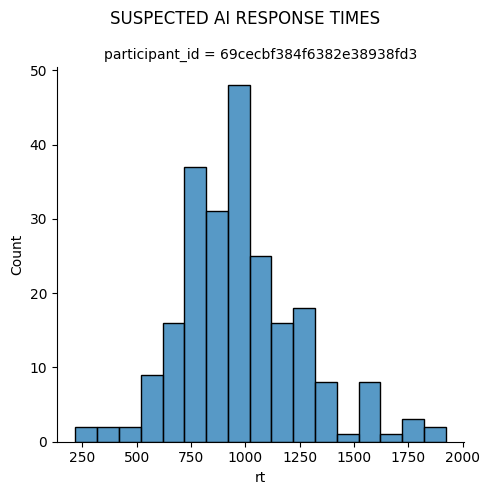

np.float64(0.631578947368421)

In [51]:
ai_participants = space_df.participant_id.unique()

sns.displot(x='rt', data=df[(df.participant_id.isin(ai_participants)) & (df.is_choice_trial)], col='participant_id')
plt.suptitle('SUSPECTED AI RESPONSE TIMES')
plt.tight_layout()
plt.show()

df[(df.participant_id.isin(ai_participants)) & (df.is_choice_trial)].optimal_old_choice.mean()

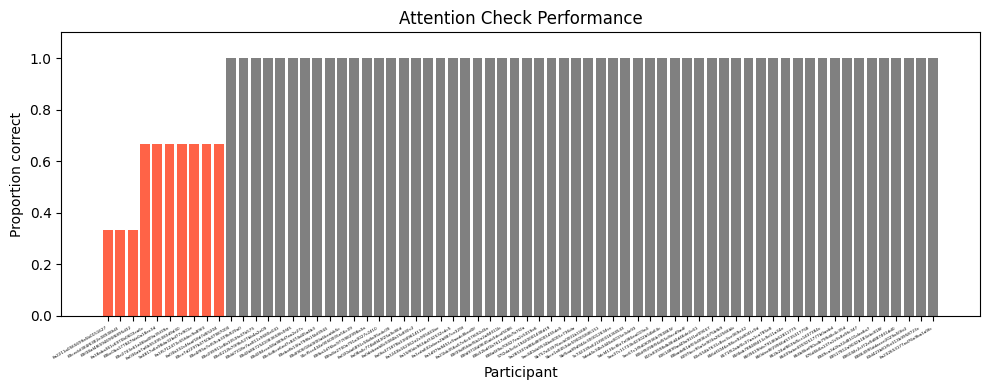

In [52]:
# plot attention check performance per subject
attention_df = df.query('is_attention_check == True').copy()

# Detect AI (hidden-key) participants early so we can color them here
# old data used space bar; new data uses 'x' -- screen for both
space_df = attention_df.query('response_key == " " or response == " " or response_key == "x" or response == "x"')
AI_PIDS = space_df['participant_id'].unique().tolist()

plot_df = attention_df.groupby('participant_id', as_index=False).agg({'correct': 'mean'})
plot_df = plot_df.sort_values('correct').reset_index(drop=True)
plot_df['x'] = np.arange(len(plot_df))

FAILED_ATTENTION_PIDS = plot_df.query('correct < 0.8')['participant_id'].tolist()

colors = ['tomato' if pid in FAILED_ATTENTION_PIDS else 'gray' for pid in plot_df['participant_id']]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(plot_df['x'], plot_df['correct'], color=colors)
ax.set_title('Attention Check Performance')
ax.set_ylabel('Proportion correct')
ax.set_xlabel('Participant')
ax.set_xticks(plot_df['x'])
ax.set_xticklabels(plot_df['participant_id'], rotation=30, ha='right', fontsize=3)
ax.set_ylim(0, 1.1)

plt.tight_layout()
if save:
    plt.savefig(os.path.join(figures_dir, 'attention_checks.png'))
plt.show()

# Overall

In [42]:
ALL_EXCLUDED_PIDS = set(FAILED_ATTENTION_PIDS + AI_PIDS)

33 out of 68 participants significantly above chance (one-sample t-test, p < 0.05, one-tailed)


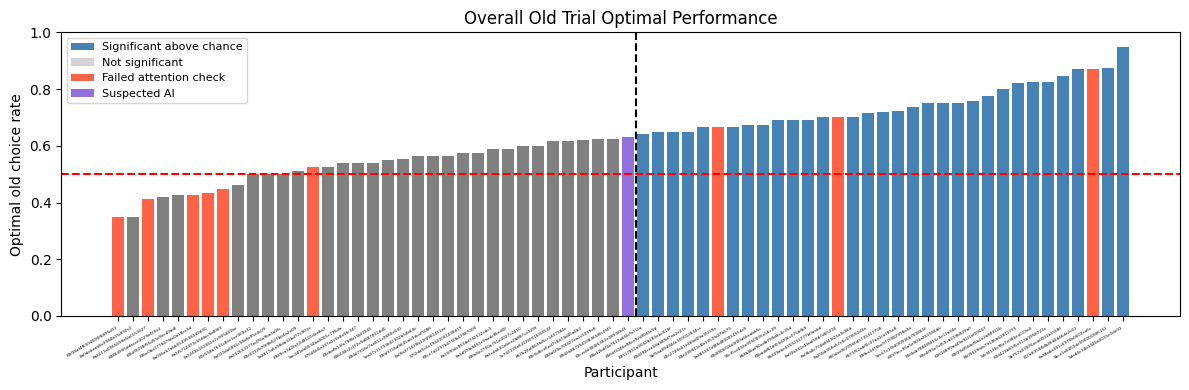

In [43]:
from scipy import stats
from matplotlib.patches import Patch

old_trials_df = df.query('old_trial == 1').dropna(subset=['optimal_old_choice']).copy()

# One-sample t-test per subject against chance (0.5), one-tailed
def subject_ttest(g):
    t, p = stats.ttest_1samp(g['optimal_old_choice'], 0.5, alternative='greater')
    return pd.Series({'pval': p, 'significant': p < 0.05})

ttest_df = old_trials_df.groupby('participant_id').apply(subject_ttest, include_groups=False).reset_index()

plot_df = old_trials_df.groupby('participant_id', as_index=False).agg({'optimal_old_choice': 'mean'})
plot_df = plot_df.merge(ttest_df, on='participant_id')

# Sort: non-significant first, then significant; within each group sort by performance
plot_df['sig_order'] = plot_df['significant'].astype(int)
plot_df = plot_df.sort_values(['sig_order', 'optimal_old_choice']).reset_index(drop=True)
plot_df['x'] = np.arange(len(plot_df))

def overall_bar_color(row):
    if row['participant_id'] in AI_PIDS:
        return 'mediumpurple'
    elif row['participant_id'] in FAILED_ATTENTION_PIDS:
        return 'tomato'
    elif row['significant']:
        return 'steelblue'
    return 'gray'

colors = [overall_bar_color(row) for _, row in plot_df.iterrows()]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(plot_df['x'], plot_df['optimal_old_choice'], color=colors)
ax.set_title('Overall Old Trial Optimal Performance')
ax.set_xlabel('Participant')
ax.set_ylabel('Optimal old choice rate')
ax.set_xticks(plot_df['x'])
ax.set_xticklabels(plot_df['participant_id'], rotation=30, ha='right', fontsize=3)
ax.axhline(y=0.5, linestyle='dashed', color='red')
ax.set_ylim(0, 1)

# Vertical line between non-significant and significant participants
n_not_sig = int((~plot_df['significant']).sum())
if 0 < n_not_sig < len(plot_df):
    ax.axvline(x=n_not_sig - 0.5, color='black', linestyle='--', linewidth=1.5)

n_sig = int(plot_df['significant'].sum())
n_total = len(plot_df)
print(f'{n_sig} out of {n_total} participants significantly above chance (one-sample t-test, p < 0.05, one-tailed)')

legend_elements = [
    Patch(facecolor='steelblue', label='Significant above chance'),
    Patch(facecolor='lightgray', label='Not significant'),
    Patch(facecolor='tomato', label='Failed attention check'),
    Patch(facecolor='mediumpurple', label='Suspected AI'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=8)

plt.tight_layout()
if save:
    plt.savefig(os.path.join(figures_dir, 'optimal_subject.png'))
plt.show()

In [30]:
sig_df = plot_df[plot_df['significant']]
sig_clean_df = df[df['participant_id'].isin(sig_df['participant_id']) & ~df['participant_id'].isin(ALL_EXCLUDED_PIDS)].query('old_trial == 1').dropna(subset=['optimal_old_choice'])

In [ ]:
##### print out list of all participant_id,final_bonus

# bonus_df = df.groupby('participant_id', as_index=False).agg({'final_bonus': 'max'})
# bonus_df = bonus_df.sort_values('participant_id')
# print('For bonus payment: ')
# for i,row in bonus_df.iterrows():
#     print(f'{row.participant_id},{row.final_bonus}')

# Old Trial Performance

In [ ]:
# average + error bars, with subject points + connecting lines in light gray behind
old_trials_df = df.query('old_trial == 1').copy()
plot_df = old_trials_df.groupby(['participant_id', 'old_value'], as_index=False).agg({'old_chosen': 'mean'})

sns.lineplot(x='old_value', y='old_chosen', units='participant_id', estimator=None, data=plot_df, 
             color='lightgray')
sns.pointplot(x='old_value', y='old_chosen', data=plot_df, errorbar='se', color='tab:blue', native_scale=True) # mean
plt.title('Old Trial Performance')
plt.ylabel('Old card chosen')
plt.xlabel('Old card value')
xmin, xmax = plot_df['old_value'].min() - 0.1, plot_df['old_value'].max() + 0.1
plt.hlines(y=0.5,xmin=xmin,xmax=xmax,linestyles='dashed',colors='gray')
plt.xlim(xmin, xmax)
if save:
    plt.savefig(os.path.join(figures_dir, 'optimal.png'))
plt.show()


In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10, 4))
fig.suptitle('Old Trial Performance by Delay')

plot_df = old_trials_df.groupby(['participant_id', 'delay', 'old_value'], as_index=False).agg({'old_chosen': 'mean'})
sns.pointplot(x='delay', y='old_chosen', hue='old_value', data=plot_df, ax=ax[0])
ax[0].set_title('All Participants')
ax[0].set_ylabel('Old card chosen')
ax[0].set_xlabel('Encoding-retrieval delay')
ax[0].hlines(y=0.5, xmin=0, xmax=8, linestyles='dashed', colors='gray')

plot_df = sig_clean_df.groupby(['participant_id', 'delay', 'old_value'], as_index=False).agg({'old_chosen': 'mean'})
sns.pointplot(x='delay', y='old_chosen', hue='old_value', data=plot_df, ax=ax[1])
ax[1].set_title('Included (attention checks + significant optimal choice)')
ax[1].set_ylabel('Old card chosen')
ax[1].set_xlabel('Encoding-retrieval delay')
ax[1].hlines(y=0.5, xmin=0, xmax=8, linestyles='dashed', colors='gray')

plt.tight_layout()
if save:
    plt.savefig(os.path.join(figures_dir, 'optimal_delay.png'))
plt.show()

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10, 4))
fig.suptitle('Old Trial Performance by Memorability')

plot_df = old_trials_df.groupby(['participant_id', 'memorability_bin', 'old_value'], as_index=False).agg({'old_chosen': 'mean'})
sns.pointplot(hue='memorability_bin', y='old_chosen', x='old_value', data=plot_df, dodge=True, 
              hue_order=['low', 'mid', 'high'], ax=ax[0], native_scale=True)
ax[0].set_title('All Participants')
ax[0].set_ylabel('Old card chosen')
ax[0].set_xlabel('Old card value')
ax[0].hlines(y=0.5, xmin=-0.1, xmax=1.1, linestyles='dashed', colors='gray')

plot_df = sig_clean_df.groupby(['participant_id', 'memorability_bin', 'old_value'], as_index=False).agg({'old_chosen': 'mean'})
sns.pointplot(hue='memorability_bin', y='old_chosen', x='old_value', data=plot_df, dodge=True, 
              hue_order=['low', 'mid', 'high'], ax=ax[1], native_scale=True)
ax[1].set_title('Included (attention checks + significant optimal choice)')
ax[1].set_ylabel('Old card chosen')
ax[1].set_xlabel('Old card value')
ax[1].hlines(y=0.5, xmin=-0.1, xmax=1.1, linestyles='dashed', colors='gray')

plt.tight_layout()
if save:
    plt.savefig(os.path.join(figures_dir, 'optimal_mem.png'))
plt.show()

# RT

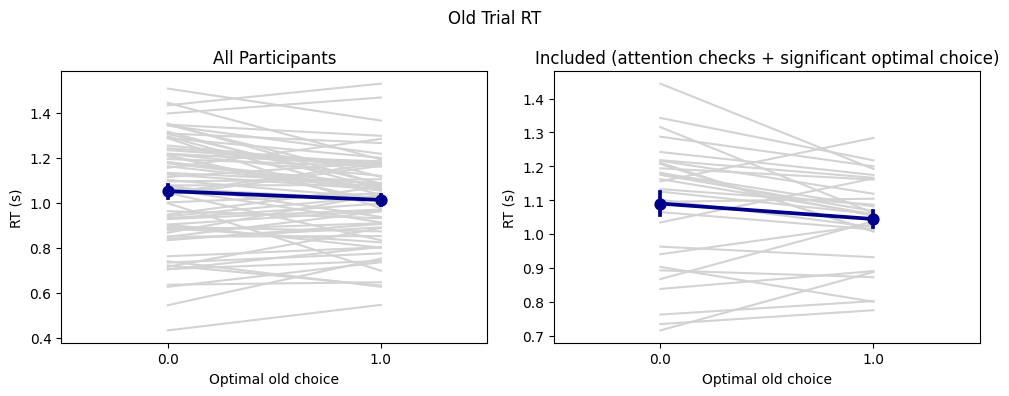

In [32]:
old_trials_df = sig_clean_df.copy()
old_trials_df['rt_sec'] = old_trials_df['rt'] / 1000

all_rt_df = df.query('old_trial == 1').dropna(subset=['optimal_old_choice']).copy()
all_rt_df['rt_sec'] = all_rt_df['rt'] / 1000

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Old Trial RT')

plot_df = all_rt_df.groupby(['participant_id', 'optimal_old_choice'], as_index=False).agg({'rt_sec': 'mean'})
sns.lineplot(x='optimal_old_choice', y='rt_sec', units='participant_id', estimator=None, data=plot_df, color='lightgray', ax=ax[0])
sns.pointplot(x='optimal_old_choice', y='rt_sec', data=plot_df, errorbar='se', color='darkblue', ax=ax[0])
ax[0].set_title('All Participants')
ax[0].set_ylabel('RT (s)')
ax[0].set_xlabel('Optimal old choice')

plot_df = old_trials_df.groupby(['participant_id', 'optimal_old_choice'], as_index=False).agg({'rt_sec': 'mean'})
sns.lineplot(x='optimal_old_choice', y='rt_sec', units='participant_id', estimator=None, data=plot_df, color='lightgray', ax=ax[1])
sns.pointplot(x='optimal_old_choice', y='rt_sec', data=plot_df, errorbar='se', color='darkblue', ax=ax[1])
ax[1].set_title('Included (attention checks + significant optimal choice)')
ax[1].set_ylabel('RT (s)')
ax[1].set_xlabel('Optimal old choice')

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'rt.png'))
plt.show()


In [ ]:

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Old Trial RT by Memorability')

plot_df = all_rt_df.groupby(['participant_id', 'memorability_bin', 'old_chosen', 'old_value'], as_index=False).agg({'rt_sec': 'mean'})
sns.pointplot(hue='memorability_bin', y='rt_sec', x='old_chosen', data=plot_df, dodge=True, hue_order=['low', 'mid', 'high'], ax=ax[0])
ax[0].set_title('All Participants')
ax[0].set_ylabel('RT (s)')
ax[0].set_xlabel('Old card chosen')

plot_df = old_trials_df.groupby(['participant_id', 'memorability_bin', 'old_chosen', 'old_value'], as_index=False).agg({'rt_sec': 'mean'})
sns.pointplot(hue='memorability_bin', y='rt_sec', x='old_chosen', data=plot_df, dodge=True, hue_order=['low', 'mid', 'high'], ax=ax[1])
ax[1].set_title('Included (attention checks + significant optimal choice)')
ax[1].set_ylabel('RT (s)')
ax[1].set_xlabel('Old card chosen')

plt.tight_layout()
if save:
    plt.savefig(os.path.join(figures_dir, 'rt_mem.png'))
plt.show()

In [ ]:
col_wrap = 10

g = sns.displot(x='rt', data=df.query('is_choice_trial==True'), col='participant_id', col_wrap=col_wrap)
g.figure.suptitle('All Choice Trials', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# g = sns.displot(x='rt', data=df.query('old_trial==1'), col='participant_id', col_wrap=col_wrap)
# g.figure.suptitle('Old Trials', fontsize=16, y=1.02)
# plt.tight_layout()
# plt.savefig(os.path.join(figures_dir, 'rt_dist.png'))
# plt.show()

# Mixed memorability analysis

df.ret_type:
- 1 -> high=0, low=1
- 2 -> high=1, low=0
- 3 -> high=0, low=0
- 4 -> high=1, low=1

In [65]:
## Setup 
INCOMPLETE_PIDS = df[df.old_trial==1].groupby('participant_id').size().loc[lambda s: s < 70].index.tolist()
ALL_EXCLUDED_PIDS = set(FAILED_ATTENTION_PIDS + AI_PIDS + INCOMPLETE_PIDS)

old_mixed = df.query('old_trial == 1').copy()
old_mixed['optimal_old_choice'] = pd.to_numeric(old_mixed['optimal_old_choice'], errors='coerce')
# Which memorability bin did the participant effectively choose?
old_mixed['chose_high_mem'] = (
    ((old_mixed['chosen_side'] == 'left')  & (old_mixed['left_mem_bin']  == 'high')) |
    ((old_mixed['chosen_side'] == 'right') & (old_mixed['right_mem_bin'] == 'high'))
).astype(float)

# Human-readable labels & display order
RT_LABELS = {1: 'high=$0\nlow=$1', 2: 'high=$1\nlow=$0', 3: 'both=$0', 4: 'both=$1'}
RT_ORDER  = ['high=$0\nlow=$1', 'high=$1\nlow=$0', 'both=$0', 'both=$1']
old_mixed['ret_type_label'] = old_mixed['ret_type'].map(RT_LABELS)

even_df   = old_mixed[old_mixed['ret_type'].isin([3, 4])].copy()
uneven_df = old_mixed.dropna(subset=['optimal_old_choice']).copy()  

# Significant participants: one-sample t-test on uneven types, p < 0.05 one-tailed
def _ttest_mixed(g):
    t, p = stats.ttest_1samp(g['optimal_old_choice'].dropna(), 0.5, alternative='greater')  # ← dropna
    return pd.Series({'pval': p, 'significant': p < 0.05})

sig_mixed_summary = uneven_df.groupby('participant_id').apply(_ttest_mixed, include_groups=False).reset_index()
sig_mixed_pids = sig_mixed_summary.query('significant')['participant_id'].tolist()
print(f'{len(sig_mixed_pids)} / {df.participant_id.nunique()} participants significantly above chance on uneven trials')

sig_clean_mixed = old_mixed[
    old_mixed['participant_id'].isin(sig_mixed_pids) &
    ~old_mixed['participant_id'].isin(ALL_EXCLUDED_PIDS)
].copy()
print(f'Included n = {sig_clean_mixed.participant_id.nunique()}')

33 / 68 participants significantly above chance on uneven trials
Included n = 28


1. Check that delays are balanced for high vs. low old items

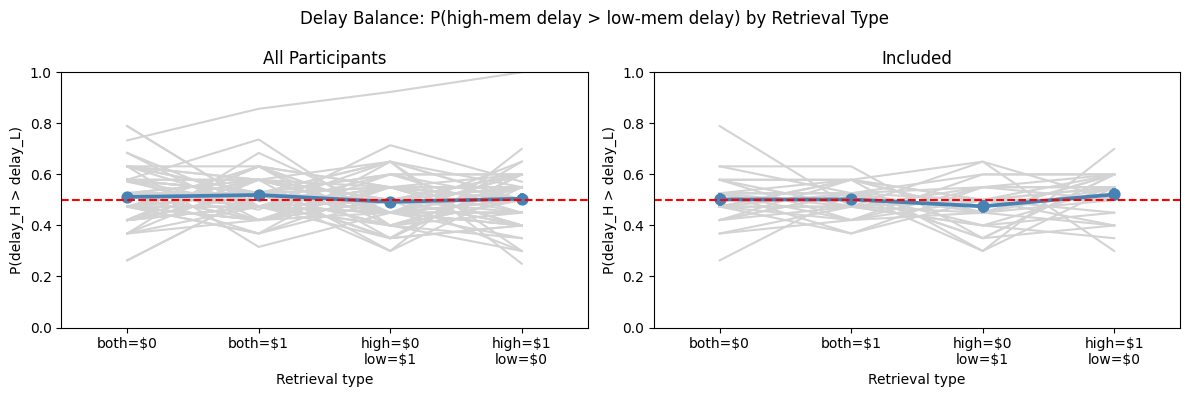

In [69]:
old_mixed['h_longer_delay'] = (old_mixed['delay_h'] > old_mixed['delay_l']).astype(float)
sig_clean_mixed['h_longer_delay'] = (sig_clean_mixed['delay_h'] > sig_clean_mixed['delay_l']).astype(float)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Delay Balance: P(high-mem delay > low-mem delay) by Retrieval Type')

for ax, (plot_data, title) in zip(axes, [
    (old_mixed,       'All Participants'),
    (sig_clean_mixed, 'Included'),
]):
    plot_df = plot_data.groupby(['participant_id', 'ret_type_label'], as_index=False).agg({'h_longer_delay': 'mean'})
    sns.lineplot(x='ret_type_label', y='h_longer_delay', units='participant_id', estimator=None,
                 data=plot_df, color='lightgray', ax=ax)
    sns.pointplot(x='ret_type_label', y='h_longer_delay', data=plot_df, errorbar='se',
                  color='steelblue', order=RT_ORDER, ax=ax)
    ax.axhline(0.5, linestyle='dashed', color='red')
    ax.set_title(title)
    ax.set_ylabel('P(delay_H > delay_L)')
    ax.set_xlabel('Retrieval type')
    ax.set_ylim(0, 1)


plt.tight_layout()
if save:
    plt.savefig(os.path.join(figures_dir, 'mixed_delay_balance.png'))
plt.show()

2. RT

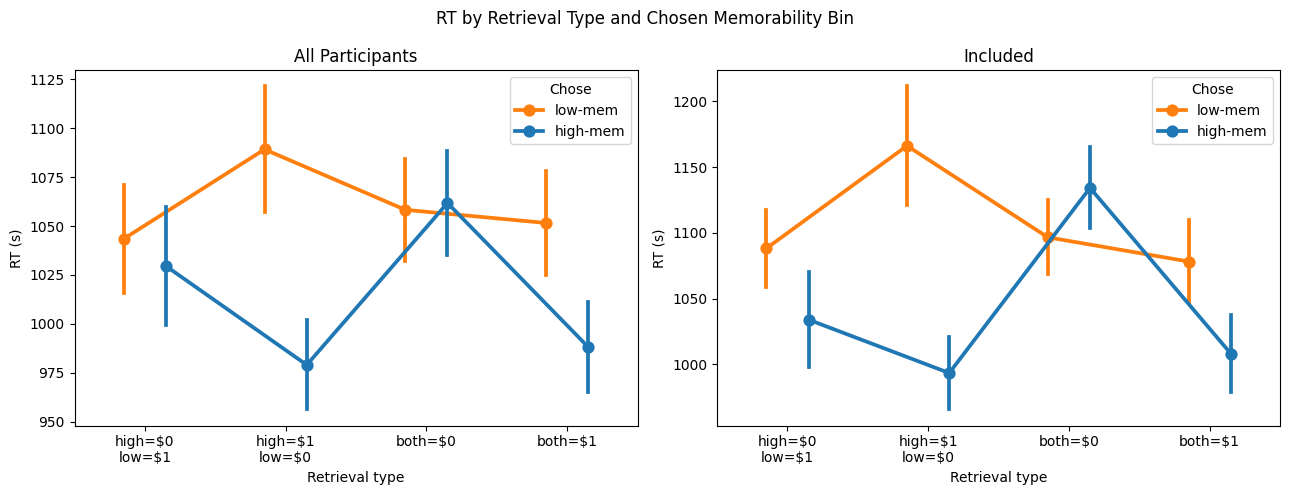

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('RT by Retrieval Type and Chosen Memorability Bin')

for ax, (plot_data, title) in zip(axes, [
    (old_mixed,       'All Participants'),
    (sig_clean_mixed, 'Included'),
]):
    plot_df = (plot_data
               .groupby(['participant_id', 'ret_type_label', 'chose_high_mem'], as_index=False)
               .agg({'rt': 'mean'}))
    sns.pointplot(x='ret_type_label', y='rt', hue='chose_high_mem',
              data=plot_df, errorbar='se', order=RT_ORDER,
              dodge=0.3, ax=ax,
              palette={0.0: 'tab:orange', 1.0: 'tab:blue'},
              hue_order=[0.0, 1.0])

    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=['low-mem', 'high-mem'], title='Chose')
    ax.set_title(title)
    ax.set_ylabel('RT (s)')
    ax.set_xlabel('Retrieval type')

plt.tight_layout()
if save:
    plt.savefig(os.path.join(figures_dir, 'mixed_rt_by_type.png'))
plt.show()

3. Optimal choice on uneven trials

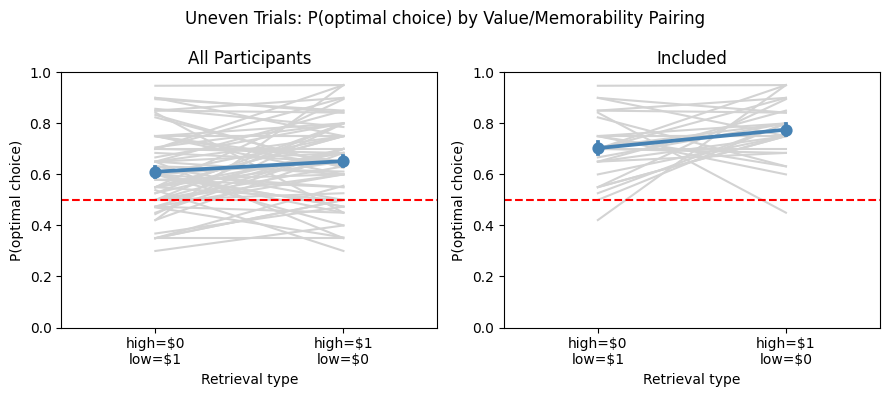

In [73]:
UNEVEN_ORDER = ['high=$0\nlow=$1', 'high=$1\nlow=$0']

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
fig.suptitle('Uneven Trials: P(optimal choice) by Value/Memorability Pairing')

for ax, (plot_data, title) in zip(axes, [
    (old_mixed.dropna(subset=['optimal_old_choice']),       'All Participants'),
    (sig_clean_mixed.dropna(subset=['optimal_old_choice']), 'Included'),
]):
    plot_df = plot_data.groupby(['participant_id', 'ret_type_label'], as_index=False).agg({'optimal_old_choice': 'mean'})
    sns.lineplot(x='ret_type_label', y='optimal_old_choice', units='participant_id', estimator=None,
                 data=plot_df, color='lightgray', ax=ax)
    sns.pointplot(x='ret_type_label', y='optimal_old_choice', data=plot_df,
                  errorbar='se', color='steelblue', order=UNEVEN_ORDER, ax=ax)
    ax.axhline(0.5, linestyle='dashed', color='red')
    ax.set_title(title)
    ax.set_ylabel('P(optimal choice)')
    ax.set_xlabel('Retrieval type')
    ax.set_ylim(0, 1)

plt.tight_layout()
if save:
    plt.savefig(os.path.join(figures_dir, 'mixed_uneven_optimal.png'))
plt.show()

4. EVEN TRIALS -- MEMORABILITY BIAS?

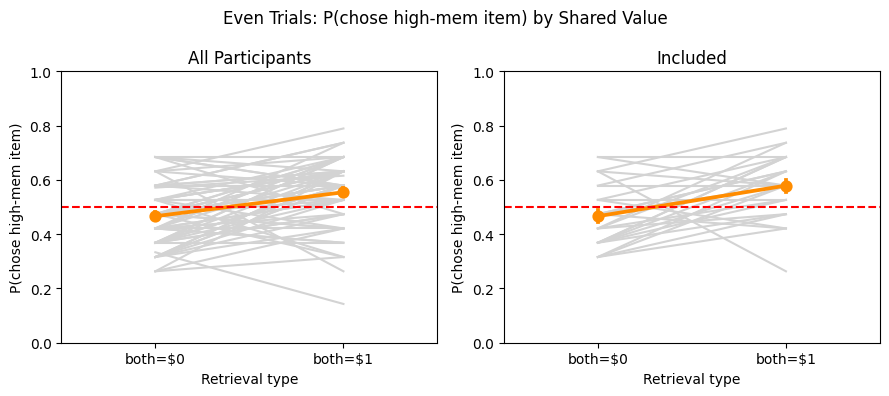

In [74]:
EVEN_ORDER = ['both=$0', 'both=$1']

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
fig.suptitle('Even Trials: P(chose high-mem item) by Shared Value')

for ax, (plot_data, title) in zip(axes, [
    (old_mixed.query('ret_type in [3, 4]'),       'All Participants'),
    (sig_clean_mixed.query('ret_type in [3, 4]'), 'Included'),
]):
    plot_df = plot_data.groupby(['participant_id', 'ret_type_label'], as_index=False).agg({'chose_high_mem': 'mean'})
    sns.lineplot(x='ret_type_label', y='chose_high_mem', units='participant_id', estimator=None,
                 data=plot_df, color='lightgray', ax=ax)
    sns.pointplot(x='ret_type_label', y='chose_high_mem', data=plot_df,
                  errorbar='se', color='darkorange', order=EVEN_ORDER, ax=ax)
    ax.axhline(0.5, linestyle='dashed', color='red')
    ax.set_title(title)
    ax.set_ylabel('P(chose high-mem item)')
    ax.set_xlabel('Retrieval type')
    ax.set_ylim(0, 1)

plt.tight_layout()
if save:
    plt.savefig(os.path.join(figures_dir, 'mixed_even_mem_bias.png'))
plt.show()

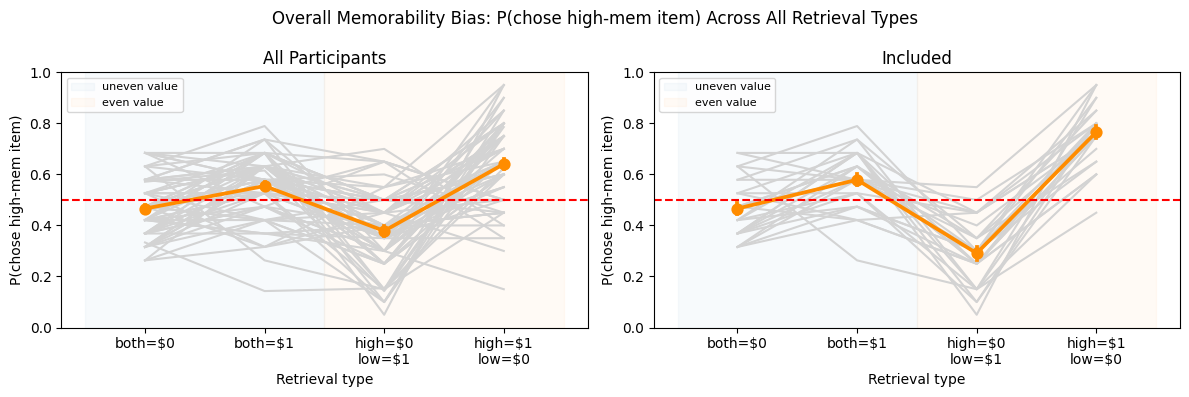

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Overall Memorability Bias: P(chose high-mem item) Across All Retrieval Types')

for ax, (plot_data, title) in zip(axes, [
    (old_mixed,       'All Participants'),
    (sig_clean_mixed, 'Included'),
]):
    plot_df = plot_data.groupby(['participant_id', 'ret_type_label'], as_index=False).agg({'chose_high_mem': 'mean'})
    sns.lineplot(x='ret_type_label', y='chose_high_mem', units='participant_id', estimator=None,
                 data=plot_df, color='lightgray', ax=ax)
    sns.pointplot(x='ret_type_label', y='chose_high_mem', data=plot_df,
                  errorbar='se', color='darkorange', order=RT_ORDER, ax=ax)
    ax.axhline(0.5, linestyle='dashed', color='red')
    ax.set_title(title)
    ax.set_ylabel('P(chose high-mem item)')
    ax.set_xlabel('Retrieval type')
    ax.set_ylim(0, 1)
    # shade uneven vs even region
    ax.axvspan(-0.5, 1.5, alpha=0.04, color='steelblue', label='uneven value')
    ax.axvspan(1.5, 3.5, alpha=0.04, color='darkorange', label='even value')
    ax.legend(fontsize=8)

plt.tight_layout()
if save:
    plt.savefig(os.path.join(figures_dir, 'mixed_mem_bias_all_types.png'))
plt.show()